In [ ]:
import numpy as np

from scipy.signal import find_peaks, czt, welch
from scipy.stats import linregress, skew, kurtosis
from itertools import permutations
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
def get_timestamp(center, window_size):
    return [center - window_size/2, center + window_size/2]

def create_timestamps(window_sizes):

    class Timestamps:
        Q1_1 = [get_timestamp(12, window_sizes[1, 1])]
        Q1_2 = [get_timestamp(26, window_sizes[1, 2])]

        # Q1_1 = [get_timestamp(10, window_sizes[1, 1])]
        # Q1_2 = [get_timestamp(24, window_sizes[1, 2])]

        Q2_1 = [get_timestamp(6, window_sizes[2, 1])]
        Q2_2 = [get_timestamp(12, window_sizes[2, 2])]

        Q3_1 = [get_timestamp(19, window_sizes[3, 1])]
        Q3_2 = [get_timestamp(40, window_sizes[3, 2])]

        Q4_1 = [get_timestamp(15, window_sizes[4, 1])]
        Q4_2 = [get_timestamp(15, window_sizes[4, 2])]

        Q5_1 = [get_timestamp(15, window_sizes[5, 1])]
        Q5_2 = [get_timestamp(10, window_sizes[5, 2])]

        Q6_1 = [get_timestamp(84, window_sizes[6, 1])]
        Q6_2 = [get_timestamp(15, window_sizes[6, 2])]

        Q7_1 = [get_timestamp(40, window_sizes[7, 1])]
        Q7_2 = [get_timestamp(40, window_sizes[7, 2])]
        
        Q8_1 = [get_timestamp(15, window_sizes[8, 1])]
        Q8_2 = [get_timestamp(12, window_sizes[8, 2])]

        Q9_1 = [get_timestamp(15, window_sizes[9, 1])]
        Q9_2 = [get_timestamp(15, window_sizes[9, 2])]

    return Timestamps

In [3]:
results = []

In [4]:
common_window_size = 3
window_sizes = np.ones((9, 2))*common_window_size

# common_window_size = 5
# window_sizes = np.ones((9, 2))*5
# window_sizes[0:2][:] = 3

print(window_sizes)

window_sizes = np.pad(window_sizes, ((1, 0), (1, 0)), mode='constant')

#print(window_sizes)

[[3. 3.]
 [3. 3.]
 [3. 3.]
 [3. 3.]
 [3. 3.]
 [3. 3.]
 [3. 3.]
 [3. 3.]
 [3. 3.]]


In [5]:
quadrants_all = [
    "Q1_1",
    "Q1_2",
    "Q2_1",
    "Q2_2",
    "Q3_1",
    "Q3_2",
    "Q4_1",
    "Q4_2",
    "Q5_1",
    "Q5_2",
    "Q6_1",
    "Q6_2",
    "Q7_1",
    "Q7_2",
    "Q8_1",
    "Q8_2",
    "Q9_1",
    "Q9_2"
]

quadrants_arousal = [
    "Q1_1",
    "Q1_2",
    "Q2_1",
    "Q2_2",
    "Q3_1",
    "Q3_2",
    "Q7_1",
    "Q7_2",
    "Q8_1",
    "Q8_2",
    "Q9_1",
    "Q9_2"
]

quadrants_valence = [
    "Q1_1",
    "Q1_2",
    "Q3_1",
    "Q3_2",
    "Q4_1",
    "Q4_2",
    "Q6_1",
    "Q6_2",
    "Q7_1",
    "Q7_2",
    "Q9_1",
    "Q9_2"
]

quadrants_5q = [
    "Q1_1",
    "Q1_2",
    "Q3_1",
    "Q3_2",
    "Q5_1",
    "Q5_2",
    "Q7_1",
    "Q7_2",
    "Q9_1",
    "Q9_2"
]


quadrants_4q = [
    "Q1_1",
    "Q1_2",
    "Q3_1",
    "Q3_2",
    "Q7_1",
    "Q7_2",
    "Q9_1",
    "Q9_2"
]

In [6]:
quadrants = quadrants_4q

In [7]:
base_path_video = "../BVPs"

failed_masks = [
    [2, "Q1_1"],
    [52, "Q7_2"],
    [53, "Q4_2"]
]

label_map = {
    "Q1": "Q1: ↑Arousal ↓Val",
    "Q2": "Q2: ↑Arousal -Val",
    "Q3": "Q3: ↑Arousal ↑Val",
    "Q4": "Q4: -Arousal ↓Val",
    "Q5": "Q5: -Arousal -Val",
    "Q6": "Q6: -Arousal ↑Val",
    "Q7": "Q7: ↓Arousal ↓Val",
    "Q8": "Q8: ↓Arousal -Val",
    "Q9": "Q9: ↓Arousal ↑Val",
}

patients = list(range(1, 62))
patients.remove(23)

#patients = expressive

class BVP:
    def __init__(self, patient, quadrant, signal, features, id):
        self.patient = patient
        self.quadrant = quadrant
        self.signal = signal
        self.features = features
        self.id = id

In [8]:
def cut_bvp(bvp, t_start, t_end, fs=60):
    n = len(bvp)

    # Convert time to sample indices
    n_start = int(t_start * fs)
    n_end = int(t_end * fs)

    # Clamp to valid range
    n_start = max(0, min(n_start, n))
    n_end = max(0, min(n_end, n))

    return bvp[n_start:n_end]

# def cut_bvp(bvp, t_start, t_end, fs = 60):

#     n_start = int(t_start * fs)
#     n_end   = int(t_end * fs) if t_end is not None else len(bvp)
#     return bvp[n_start:n_end]

In [9]:
def get_label(path):
    q = path.split("_")[0]  # "Q3_2" → "Q3"
    return label_map[q]

# def get_label(path):
#     q = path.split("_")[0]

#     if q in ["Q1", "Q3"]:
#         return "HighArousal"
#     else:
#         return "LowArousal"

In [21]:
def compute_features_both(timestamps, bvp, fs):
    """
    Compute BVP features from a single short window.
    Returns a dictionary (same format as previous function).
    """

    patient, quadrant = bvp.patient, bvp.quadrant

    bvp = np.asarray(bvp.signal)

    if len(bvp) < fs:  # less than 1 second
        return None

    # ---- Remove DC component ----
    bvp = bvp - np.mean(bvp)

    # ---- Time-domain features ----
    features = {}

    features["bvp_std"] = np.std(bvp)
    features["bvp_min"] = np.min(bvp)
    features["bvp_max"] = np.max(bvp)
    features["bvp_ptp"] = np.ptp(bvp)              # peak-to-peak
    features["bvp_energy"] = np.sum(bvp ** 2)
    features["bvp_skew"] = skew(bvp)
    features["bvp_kurtosis"] = kurtosis(bvp)

    # ---- Frequency-domain features ----
    # freqs, psd = welch(bvp, fs=fs)
    freqs, psd = welch(bvp, fs=fs, nperseg=len(bvp))

    features["bvp_total_power"] = np.sum(psd)
    features["bvp_dominant_freq"] = freqs[np.argmax(psd)]

    # ---------------- GESTURE FEATURES ----------------

    patient = f"Patient_{patient}"

    #print(f"Computing Gesture Features for {patient}...", end="\r", flush=True)

    path = rf"C:\Users\mique\OneDrive\Dokumenty\GitHub\POS\Gesture Emotion Prediction\Results\{patient}\{quadrant}\vid_crop.csv"

    df = pd.read_csv(path)

    # keep only valid frames
    if "success" in df.columns:
        df = df[df["success"] == 1]
        
    for t_start, t_end in getattr(timestamps, quadrant):

        df_window = df[(df[" timestamp"] >= t_start) & (df[" timestamp"] <= t_end)]

        # select AU intensity columns
        au_cols = [c for c in df_window.columns if "_r" in c]

        for col in au_cols:
            features[f"{col}"] = df_window[col].mean()

        # for col in au_cols:
        #     features[f"{col}_mean"] = df_window[col].mean()
        #     features[f"{col}_std"] = df_window[col].std()
        #     features[f"{col}_max"] = df_window[col].max()

    return features

In [13]:
timestamps = create_timestamps(window_sizes)

In [ ]:
# Load BVPs

fs = 60  # sampling rate

BVPs = []

for patient in patients:

    for quadrant in quadrants:

        if [patient, quadrant] in failed_masks:
            print(f"Skipping Patient_{patient}, {quadrant}")
            continue

        data = np.load(f"{base_path_video}/Patient_{patient}/{quadrant}.npy")

        for t_start, t_end in getattr(timestamps, quadrant):

            data_cut = cut_bvp(data, t_start, t_end, fs)

            id = f"{patient}{quadrant}"

            bvp = BVP(patient, quadrant, data_cut, [], id)

            BVPs.append(bvp)

            #print(f"Patient_{patient}, {path}: {data.shape}")

print(f"Loaded {len(BVPs)} BVP signals")


Skipping Patient_2, Q1_1
Skipping Patient_52, Q7_2
Loaded 478 BVP signals


In [33]:
valid = []
failed = []

for bvp in BVPs:  # use a copy to safely remove items

    print(f"Computing Features for Patient_{bvp.patient}...", end="\r", flush=True)
    
    try:
        # Use the new windowed feature extraction
        feats = compute_features_both(timestamps, bvp, fs)

        if feats is None or feats == []:
            print(f"Failed: Patient_{bvp.patient}, {bvp.quadrant}")
            failed.append(f"Patient_{bvp.patient}, {bvp.quadrant}")
            BVPs.remove(bvp)  # remove problematic signal
        else:
            bvp.features = feats
            valid.append(f"Patient_{bvp.patient}, {bvp.quadrant}")

    except Exception as e:
        print(f"Error for Patient_{bvp.patient}, {bvp.quadrant}: {e}")
        failed.append(f"Patient_{bvp.patient}, {bvp.quadrant}")
        BVPs.remove(bvp)

print(f"Extracted features for {len(valid)} videos")
print(f"Failed: {failed}")

Extracted features for 475 videos...
Failed: []


In [ ]:
pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ])

X = []
y = []
groups = []

for bvp in BVPs:
    if bvp is None or bvp.features == []:
        print("Error: Patient", bvp.patient, bvp.path)
        continue
    
    feat_values = list(bvp.features.values())
    X.append(feat_values)
    y.append(get_label(bvp.quadrant))
    groups.append(bvp.id)  
    

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)
print(np.unique(y, return_counts=True))
print("Example of data: ", X[0])

(475, 26) (475,)
(array(['Q1: ↑Arousal ↓Val', 'Q3: ↑Arousal ↑Val', 'Q7: ↓Arousal ↓Val',
       'Q9: ↓Arousal ↑Val'], dtype='<U17'), array([118, 119, 118, 120], dtype=int64))
Example of data:  [ 0.10038911 -0.19378608  0.18842487  0.38221095  1.81403507  0.17419632
 -0.83760512  0.03769196  1.33333333  0.31889503  0.05265193  0.5379558
  0.01524862  0.8119337   0.66475138  0.14248619  1.42690608  0.98088398
  0.99679558  0.09867403  0.26718232  0.09922652  0.16325967  0.25298343
  0.19486188  0.21342541]


In [39]:
cv = StratifiedGroupKFold(n_splits=5)

classif_reports = []
conf_matrix = []
f1_scores = []

from collections import Counter
print("Class distribution:", Counter(y))

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    print(f"Fold {fold}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    pipe.fit(X_train, y_train)
    score = pipe.score(X_test, y_test)

    print("Score:", score)

    y_pred = pipe.predict(X_test)

    report_dict = classification_report(y_test, y_pred, output_dict=True)

    classif_reports.append(classification_report(y_test, y_pred))
    conf_matrix.append(confusion_matrix(y_test, y_pred))
    f1_scores.append(report_dict["macro avg"]["f1-score"])


Class distribution: Counter({'Q9: ↓Arousal ↑Val': 120, 'Q3: ↑Arousal ↑Val': 119, 'Q1: ↑Arousal ↓Val': 118, 'Q7: ↓Arousal ↓Val': 118})
Fold 0
Score: 0.3894736842105263
Fold 1
Score: 0.42105263157894735
Fold 2
Score: 0.3473684210526316
Fold 3
Score: 0.4895833333333333
Fold 4
Score: 0.43617021276595747


In [40]:
report, matrix, f1_scores = classif_reports, conf_matrix, f1_scores

In [41]:
print("F1-Scores:", [f"{score:.2f}" for score in f1_scores[:5]])
print()
print(f"Average F1-Score: {sum(f1_scores)/5}")
print()
for idx in range(5):
    print(report[idx])
    print(matrix[idx])
    print()
    print("-"*50)

F1-Scores: ['0.39', '0.43', '0.35', '0.48', '0.43']

Average F1-Score: 0.4166430573312474

                   precision    recall  f1-score   support

Q1: ↑Arousal ↓Val       0.38      0.33      0.36        24
Q3: ↑Arousal ↑Val       0.48      0.50      0.49        24
Q7: ↓Arousal ↓Val       0.35      0.39      0.37        23
Q9: ↓Arousal ↑Val       0.35      0.33      0.34        24

         accuracy                           0.39        95
        macro avg       0.39      0.39      0.39        95
     weighted avg       0.39      0.39      0.39        95

[[ 8  9  4  3]
 [ 5 12  3  4]
 [ 4  2  9  8]
 [ 4  2 10  8]]

--------------------------------------------------
                   precision    recall  f1-score   support

Q1: ↑Arousal ↓Val       0.43      0.39      0.41        23
Q3: ↑Arousal ↑Val       0.65      0.54      0.59        24
Q7: ↓Arousal ↓Val       0.36      0.38      0.37        24
Q9: ↓Arousal ↑Val       0.31      0.38      0.34        24

         accuracy       

In [42]:
import pandas as pd

# feature names from BVP objects (windowed)
feature_names = list(BVPs[0].features.keys())

# extract RF importances from pipeline
importances = pipe.named_steps['clf'].feature_importances_

# build DataFrame
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(imp_df)


              feature  importance
15             AU09_r    0.066754
17             AU12_r    0.055047
23             AU25_r    0.052457
20             AU17_r    0.051337
25             AU45_r    0.047845
13             AU06_r    0.047080
19             AU15_r    0.046160
14             AU07_r    0.043292
12             AU05_r    0.042052
10             AU02_r    0.041496
6        bvp_kurtosis    0.040270
9              AU01_r    0.040264
22             AU23_r    0.038578
11             AU04_r    0.038224
16             AU10_r    0.037920
21             AU20_r    0.036363
18             AU14_r    0.035102
5            bvp_skew    0.034771
24             AU26_r    0.034141
1             bvp_min    0.029010
7     bvp_total_power    0.028822
3             bvp_ptp    0.027216
2             bvp_max    0.026251
0             bvp_std    0.025843
4          bvp_energy    0.025256
8   bvp_dominant_freq    0.008450


In [41]:
results.append((f1_scores, common_window_size))

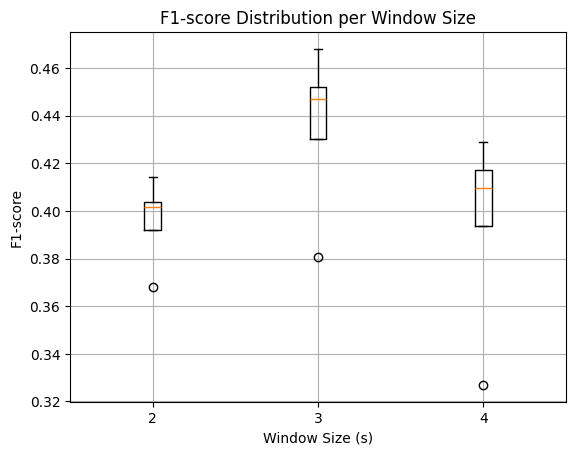

In [42]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

grouped = defaultdict(list)

for f1, win_size in results:
    grouped[win_size].append(f1)

window_sizes = sorted(grouped.keys())
f1_lists = [np.array(grouped[w]).ravel() for w in window_sizes]

plt.figure()

plt.boxplot(
    f1_lists,
    positions=window_sizes,
    widths=0.1
)

plt.xlabel("Window Size (s)")
plt.ylabel("F1-score")
plt.title("F1-score Distribution per Window Size")

plt.xticks(window_sizes)      # ensure ticks match window sizes
plt.grid(True)

plt.show()

In [43]:
# np.save("f1_scores_CUT.npy", np.array(results, dtype=object))



In [44]:
# a = np.load("f1_scores_CUT.npy", allow_pickle=True)

# for i in a:
#     print(f"Window Size: {i[1]} -> {i[0]}")